In [1]:
# Standard library and data handling
import os
import re
import plistlib
import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import defaultdict

# Radiomics
import radiomics
from radiomics import featureextractor

# Dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

All imports successful


In [2]:
# Paths to gated CT scans and calcium XML annotations
# We use the GATED scans for Project 2 because the calcium XML 
# annotations correspond to gated acquisitions
GATED_ROOT = r"D:\GSOC\ML4SCI\cocacoronarycalciumandchestcts-2\Gated_release_final\patient"
XML_ROOT   = r"D:\GSOC\ML4SCI\cocacoronarycalciumandchestcts-2\Gated_release_final\calcium_xml"
NIFTI_DIR  = r"D:\GSOC\gated_nifti"  # we'll convert gated scans here
os.makedirs(NIFTI_DIR, exist_ok=True)

# Get available patients (those with both scan and XML annotation)
xml_files = [f.replace('.xml', '') for f in os.listdir(XML_ROOT) if f.endswith('.xml')]
print(f"Found {len(xml_files)} annotated patients: {sorted(xml_files)[:10]}...")

# Use first 20 patients
patients = sorted(xml_files, key=lambda x: int(x))[:20]
print(f"\nUsing {len(patients)} patients: {patients}")

Found 451 annotated patients: ['0', '1', '10', '100', '101', '102', '103', '104', '105', '106']...

Using 20 patients: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19']


In [3]:
def convert_gated_dicom(patient_id):
    """
    Convert gated cardiac CT DICOM series to NIfTI format.
    Gated scans may have multiple phases — we use the first series.
    """
    nifti_path = os.path.join(NIFTI_DIR, f"patient_{patient_id}.nii.gz")
    
    if os.path.exists(nifti_path):
        return nifti_path  # already converted
    
    patient_path = os.path.join(GATED_ROOT, str(patient_id))
    if not os.path.exists(patient_path):
        print(f"[{patient_id}] Patient folder not found")
        return None
    
    # Find first available series folder
    series_folders = []
    for root, dirs, files in os.walk(patient_path):
        if any(f.endswith('.dcm') for f in files):
            series_folders.append(root)
    
    if not series_folders:
        print(f"[{patient_id}] No DICOM files found")
        return None
    
    dicom_dir = series_folders[0]
    
    try:
        reader = sitk.ImageSeriesReader()
        dicom_names = reader.GetGDCMSeriesFileNames(dicom_dir)
        reader.SetFileNames(dicom_names)
        image = reader.Execute()
        sitk.WriteImage(image, nifti_path)
        print(f"[{patient_id}] Converted: {image.GetSize()}, spacing: {image.GetSpacing()}")
        return nifti_path
    except Exception as e:
        print(f"[{patient_id}] Conversion failed: {e}")
        return None

# Convert all patients
print("Converting gated DICOM scans to NIfTI...\n")
nifti_paths = {}
for pid in patients:
    path = convert_gated_dicom(pid)
    if path:
        nifti_paths[pid] = path

print(f"\nSuccessfully converted: {len(nifti_paths)} patients")

Converting gated DICOM scans to NIfTI...

[12] Patient folder not found

Successfully converted: 19 patients


In [4]:
def parse_calcium_xml(patient_id):
    """
    Parse Apple plist-format calcium XML annotation.
    Returns list of ROIs with slice index, area, max HU, mean HU,
    number of points, and coronary artery territory name.
    """
    xml_path = os.path.join(XML_ROOT, f"{patient_id}.xml")
    
    with open(xml_path, 'rb') as f:
        plist_data = plistlib.load(f)
    
    rois = []
    # Each entry in Images corresponds to one CT slice
    for image_entry in plist_data.get('Images', []):
        slice_idx = image_entry.get('ImageIndex', -1)
        for roi in image_entry.get('ROIs', []):
            rois.append({
                'slice_idx':    slice_idx,
                'area_cm2':     roi.get('Area', 0),
                'max_hu':       roi.get('Max', 0),
                'mean_hu':      roi.get('Mean', 0),
                'min_hu':       roi.get('Min', 0),
                'n_points':     roi.get('NumberOfPoints', 0),
                'artery':       roi.get('Name', 'Unknown'),
                'points_mm':    roi.get('Point_mm', []),    
            })
    return rois

def compute_agatston_score(rois, slice_thickness_mm=3.0):
    """
    Compute Agatston score from calcium ROIs.
    
    Agatston scoring:
      - Only lesions with max HU > 130 are counted
      - Density factor based on peak HU:
          130-199 HU → factor 1
          200-299 HU → factor 2
          300-399 HU → factor 3
          ≥400 HU    → factor 4
      - Score per lesion = area (mm²) × density_factor
      - Normalised by slice thickness (standard is 3mm)
    
    Returns total Agatston score and per-artery breakdown.
    """
    def density_factor(max_hu):
        if max_hu < 130:  return 0
        elif max_hu < 200: return 1
        elif max_hu < 300: return 2
        elif max_hu < 400: return 3
        else:              return 4
    
    total_score = 0.0
    per_artery  = defaultdict(float)
    
    for roi in rois:
        max_hu = roi['max_hu']
        if max_hu < 130:
            continue  # below calcium threshold, skip
        
        # Convert area from cm² to mm² (1 cm² = 100 mm²)
        area_mm2 = roi['area_cm2'] * 100.0
        
        # Slice thickness normalisation factor
        thickness_factor = slice_thickness_mm / 3.0
        
        df    = density_factor(max_hu)
        score = area_mm2 * df * thickness_factor
        
        total_score          += score
        per_artery[roi['artery']] += score
    
    return total_score, dict(per_artery)

def categorise_agatston(score):
    """
    Categorise Agatston score into standard clinical risk groups.
    0: No calcium (no detectable CAD)
    1-99: Mild calcium burden
    100-399: Moderate calcium burden  
    ≥400: Severe calcium burden, high MACE risk
    """
    if score == 0:    return '0 (None)'
    elif score < 100: return '1-99 (Mild)'
    elif score < 400: return '100-399 (Moderate)'
    else:             return '≥400 (Severe)'

# Parse all patients and compute Agatston scores
print("Parsing calcium annotations and computing Agatston scores...\n")
agatston_data = {}

for pid in patients:
    try:
        rois  = parse_calcium_xml(pid)
        score, per_artery = compute_agatston_score(rois)
        agatston_data[pid] = {
            'agatston_score': score,
            'category':       categorise_agatston(score),
            'n_lesions':      len([r for r in rois if r['max_hu'] >= 130]),
            'per_artery':     per_artery,
            'total_rois':     len(rois),
        }
        print(f"Patient {pid:>3} | Agatston: {score:8.1f} | "
              f"Category: {categorise_agatston(score):<20} | "
              f"Lesions: {agatston_data[pid]['n_lesions']}")
    except Exception as e:
        print(f"Patient {pid}: Failed — {e}")

print(f"\nProcessed {len(agatston_data)} patients")

Parsing calcium annotations and computing Agatston scores...

Patient   0 | Agatston:      5.9 | Category: 1-99 (Mild)          | Lesions: 1
Patient   1 | Agatston:    369.7 | Category: 100-399 (Moderate)   | Lesions: 16
Patient   2 | Agatston:    113.7 | Category: 100-399 (Moderate)   | Lesions: 13
Patient   3 | Agatston:    470.9 | Category: ≥400 (Severe)        | Lesions: 10
Patient   4 | Agatston:     27.4 | Category: 1-99 (Mild)          | Lesions: 10
Patient   5 | Agatston:   2298.9 | Category: ≥400 (Severe)        | Lesions: 41
Patient   6 | Agatston:    341.2 | Category: 100-399 (Moderate)   | Lesions: 18
Patient   7 | Agatston:     51.9 | Category: 1-99 (Mild)          | Lesions: 4
Patient   8 | Agatston:     70.1 | Category: 1-99 (Mild)          | Lesions: 2
Patient   9 | Agatston:     72.1 | Category: 1-99 (Mild)          | Lesions: 4
Patient  10 | Agatston:    113.4 | Category: 100-399 (Moderate)   | Lesions: 18
Patient  11 | Agatston:    148.8 | Category: 100-399 (Moderate

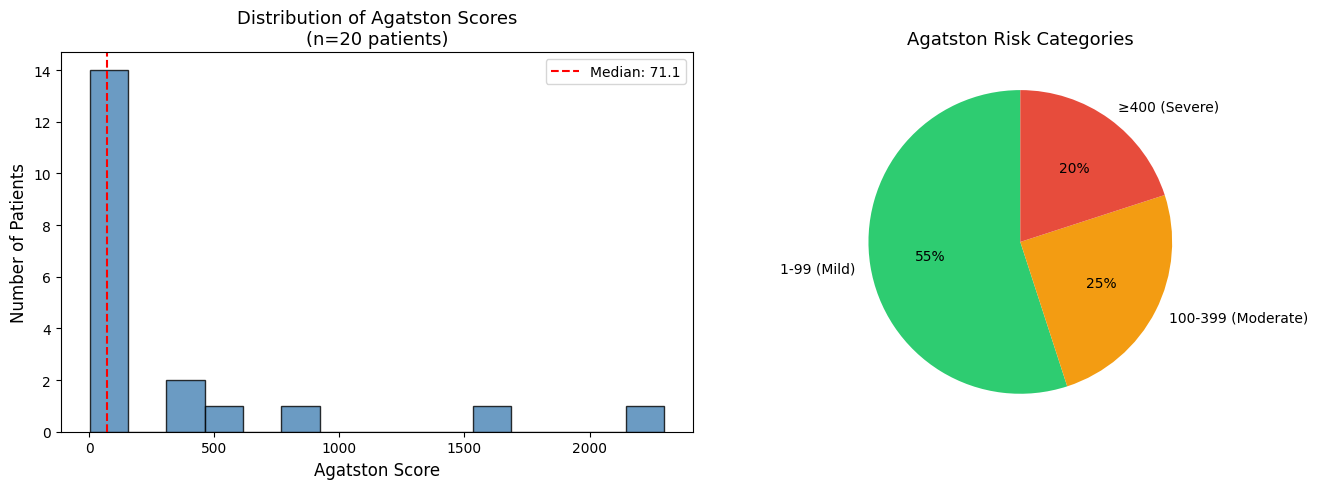


Score range: 1.6 — 2298.9
Median: 71.1, Mean: 340.0


In [5]:
# Visualise Agatston score distribution across patients
scores     = [agatston_data[p]['agatston_score'] for p in agatston_data]
categories = [agatston_data[p]['category'] for p in agatston_data]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
ax1.hist(scores, bins=15, color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_xlabel('Agatston Score', fontsize=12)
ax1.set_ylabel('Number of Patients', fontsize=12)
ax1.set_title('Distribution of Agatston Scores\n(n=20 patients)', fontsize=13)
ax1.axvline(np.median(scores), color='red', linestyle='--', 
            label=f'Median: {np.median(scores):.1f}')
ax1.legend()

# Category pie chart
cat_counts = pd.Series(categories).value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
ax2.pie(cat_counts.values, labels=cat_counts.index, 
        colors=colors[:len(cat_counts)],
        autopct='%1.0f%%', startangle=90)
ax2.set_title('Agatston Risk Categories', fontsize=13)

plt.tight_layout()
plt.savefig('agatston_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nScore range: {min(scores):.1f} — {max(scores):.1f}")
print(f"Median: {np.median(scores):.1f}, Mean: {np.mean(scores):.1f}")

In [6]:
# Diagnostic — check if slice indices align between XML and NIfTI
pid = '1'
ct_path = nifti_paths[pid]
ct_image = sitk.ReadImage(ct_path)
ct_arr = sitk.GetArrayFromImage(ct_image)
rois = parse_calcium_xml(pid)

print(f"CT shape: {ct_arr.shape}")
print(f"CT HU range: {ct_arr.min():.0f} to {ct_arr.max():.0f}")
print(f"\nXML ROI slice indices: {sorted(set(r['slice_idx'] for r in rois))}")
print(f"Total ROIs: {len(rois)}")
print(f"ROIs above 130 HU: {len([r for r in rois if r['max_hu'] >= 130])}")

# Check how many voxels are above 130 HU in annotated slices
for r in rois[:3]:
    s = r['slice_idx']
    if 0 <= s < ct_arr.shape[0]:
        n_above = (ct_arr[s] > 130).sum()
        print(f"Slice {s}: {n_above} voxels above 130 HU, ROI max HU: {r['max_hu']}")
    else:
        print(f"Slice {s}: OUT OF RANGE (CT has {ct_arr.shape[0]} slices)")

CT shape: (57, 512, 512)
CT HU range: -1024 to 1239

XML ROI slice indices: [12, 19, 26, 27, 28, 39, 40, 41]
Total ROIs: 20
ROIs above 130 HU: 16
Slice 12: 13990 voxels above 130 HU, ROI max HU: 285.0
Slice 19: 14364 voxels above 130 HU, ROI max HU: 186.0
Slice 26: 17494 voxels above 130 HU, ROI max HU: 139.0


In [7]:
# ── Cell 6: PyRadiomics Feature Extraction ──────────────────────────────────
# We extract radiomic features from the calcium regions in each patient.
# Features are extracted from the gated CT scan using a binary mask
# derived from the calcium XML annotations (voxels with HU > 130).

def create_calcium_mask(ct_image, rois, hu_threshold=130, dilation=3):
    """
    Create a 3D calcium mask from annotated ROI points.
    """
    ct_arr = sitk.GetArrayFromImage(ct_image)
    mask_arr = np.zeros_like(ct_arr, dtype=np.uint8)

    origin = np.array(ct_image.GetOrigin())
    spacing = np.array(ct_image.GetSpacing())

    valid_points = 0

    for roi in rois:
        if roi['max_hu'] < hu_threshold:
            continue

        slice_idx = roi['slice_idx']
        if not (0 <= slice_idx < ct_arr.shape[0]):
            continue

        for pt_str in roi.get('points_mm', []):
            coords = re.findall(r'[-\d.]+', str(pt_str))
            if len(coords) < 2:
                continue

            x_mm, y_mm = float(coords[0]), float(coords[1])
            xi = int(round((x_mm - origin[0]) / spacing[0]))
            yi = int(round((y_mm - origin[1]) / spacing[1]))

            for dz in range(-1, 2):
                zi = slice_idx + dz
                if not (0 <= zi < ct_arr.shape[0]):
                    continue

                for dy in range(-dilation, dilation + 1):
                    for dx in range(-dilation, dilation + 1):
                        ny, nx = yi + dy, xi + dx
                        if 0 <= ny < ct_arr.shape[1] and 0 <= nx < ct_arr.shape[2]:
                            if ct_arr[zi, ny, nx] > hu_threshold:
                                mask_arr[zi, ny, nx] = 1
                                valid_points += 1

    mask_image = sitk.GetImageFromArray(mask_arr)
    mask_image.CopyInformation(ct_image)
    return mask_image, valid_points


def extract_radiomics_features(patient_id, ct_path):
    """
    Extract PyRadiomics features from calcium regions.
    """
    settings = {
        'binWidth': 25,
        'resampledPixelSpacing': None,
        'verbose': False,
        'force2D': True,
        'force2Ddimension': 0,
    }

    extractor = featureextractor.RadiomicsFeatureExtractor(**settings)
    extractor.disableAllFeatures()
    extractor.enableFeatureClassByName('shape')
    extractor.enableFeatureClassByName('glcm')
    extractor.enableFeatureClassByName('glszm')
    extractor.enableFeatureClassByName('glrlm')
    extractor.enableFeatureClassByName('firstorder')

    try:
        ct_image = sitk.ReadImage(ct_path)
        rois = parse_calcium_xml(patient_id)
        mask_image, valid_points = create_calcium_mask(ct_image, rois)

        mask_arr = sitk.GetArrayFromImage(mask_image)
        if mask_arr.sum() < 10 or valid_points == 0:
            print(f"  [{patient_id}] Insufficient calcium voxels, skipping")
            return None

        print(f"  [{patient_id}] Mask voxels: {int(mask_arr.sum())}")

        result = extractor.execute(ct_image, mask_image, label=1)

        features = {}
        for k, v in result.items():
            if k.startswith('diagnostics_'):
                continue
            try:
                arr = np.asarray(v)
                if arr.size != 1:
                    continue
                features[k] = float(arr.reshape(-1)[0])
            except (TypeError, ValueError):
                continue

        print(f"  [{patient_id}] Retained {len(features)} numeric features")

        if len(features) == 0:
            return None

        return features

    except Exception as e:
        print(f"  [{patient_id}] Extraction failed: {e}")
        return None


# Run extraction on all patients
print("Extracting PyRadiomics features...\n")
print("(This may take 2-3 minutes per patient)\n")

all_features = {}
for pid in patients:
    if pid not in nifti_paths:
        print(f"[{pid}] No NIfTI file, skipping")
        continue

    print(f"[{pid}] Extracting features...")
    features = extract_radiomics_features(pid, nifti_paths[pid])

    if features:
        features['agatston_score'] = agatston_data[pid]['agatston_score']
        features['agatston_category'] = agatston_data[pid]['category']
        features['n_lesions'] = agatston_data[pid]['n_lesions']
        all_features[pid] = features
        print(f"  [{pid}] Done - {len(features)} features extracted")
    else:
        print(f"  [{pid}] Skipped")

print(f"\nExtracted features for {len(all_features)} patients")


Extracting PyRadiomics features...

(This may take 2-3 minutes per patient)

[0] Extracting features...
  [0] Mask voxels: 13


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


  [0] Retained 88 numeric features
  [0] Done - 91 features extracted
[1] Extracting features...
  [1] Mask voxels: 745


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


  [1] Retained 88 numeric features
  [1] Done - 91 features extracted
[2] Extracting features...
  [2] Mask voxels: 395


...

  [17] Retained 88 numeric features
  [17] Done - 91 features extracted
[18] Extracting features...
  [18] Mask voxels: 112


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


  [18] Retained 88 numeric features
  [18] Done - 91 features extracted
[19] Extracting features...
  [19] Mask voxels: 55


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


  [19] Retained 88 numeric features
  [19] Done - 91 features extracted

Extracted features for 19 patients


In [12]:
import pandas as pd

df = pd.DataFrame.from_dict(all_features, orient='index')
df.index.name = 'patient_id'
df = df.reset_index()

meta_cols = ['patient_id', 'agatston_score', 'agatston_category', 'n_lesions']
print(df.shape)
df.head()


(19, 92)


,patient_id,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,...,original_firstorder_Range,original_firstorder_RobustMeanAbsoluteDeviation,original_firstorder_RootMeanSquared,original_firstorder_Skewness,original_firstorder_TotalEnergy,original_firstorder_Uniformity,original_firstorder_Variance,agatston_score,agatston_category,n_lesions
0,0,0.365461,0.000000,0.000000,3.529063,4.136320,3.146588,3.355995,4.163460,5.856606,...,75.0,12.839506,162.378002,0.406557,2.316283e+05,0.301775,519.869822,5.856606,1-99 (Mild),1
1,1,0.290239,0.229940,24.652827,107.214010,95.204568,11.130660,28.258201,96.074475,300.582954,...,803.0,96.044253,355.909164,1.321785,4.148853e+07,0.073544,32333.302475,369.734064,100-399 (Moderate),16
2,2,0.386500,0.109744,11.119324,101.320529,6.524294,53.015315,52.710631,71.870035,106.114151,...,405.0,54.149668,241.097653,1.114525,7.067277e+06,0.129281,8034.839263,113.680908,100-399 (Moderate),13
3,3,0.529093,0.224363,8.161620,36.376913,27.758293,16.463486,33.310336,54.033649,353.588450,...,588.0,77.962973,315.326078,1.079286,3.821229e+07,0.073002,17943.177638,470.872189,≥400 (Severe),10
4,4,0.863323,0.413620,24.982529,60.399712,6.010405,21.024706,27.666974,67.615400,32.305597,...,188.0,19.559767,176.571822,1.670210,1.402693e+06,0.266806,1865.314931,27.369152,1-99 (Mild),10


In [13]:
# ── Statistical Analysis: Correlate radiomic features with Agatston score ──
# We use Spearman correlation (not Pearson) because:
# 1. Agatston scores are heavily right-skewed (not normally distributed)
# 2. Spearman is rank-based and robust to outliers like the score=2298 patient

numeric_features = [c for c in df.columns if c not in meta_cols]
agatston_scores  = df['agatston_score'].values

# Compute Spearman correlation and p-value for each feature
correlation_results = []
for feat in numeric_features:
    vals = df[feat].values
    # Skip features with zero variance
    if np.std(vals) == 0:
        continue
    rho, pval = stats.spearmanr(vals, agatston_scores)
    correlation_results.append({
        'feature':  feat,
        'spearman_rho': rho,
        'p_value':  pval,
        'significant': pval < 0.05
    })

corr_df = pd.DataFrame(correlation_results)
corr_df = corr_df.sort_values('spearman_rho', key=abs, ascending=False)

# Show significant features
sig_features = corr_df[corr_df['significant']]
print(f"Total features tested: {len(corr_df)}")
print(f"Significant correlations (p<0.05): {len(sig_features)}")
print(f"\nTop 10 features by |Spearman rho|:")
print(corr_df.head(10)[['feature', 'spearman_rho', 'p_value']].to_string())

Total features tested: 88
Significant correlations (p<0.05): 78

Top 10 features by |Spearman rho|:
                                  feature  spearman_rho       p_value
46   original_glszm_SizeZoneNonUniformity      0.989474  1.030540e-15
8               original_shape_MeshVolume      0.989474  1.030540e-15
85        original_firstorder_TotalEnergy      0.987719  3.797902e-15
13             original_shape_VoxelVolume      0.984211  3.177818e-14
72             original_firstorder_Energy      0.971930  4.055350e-12
63  original_glrlm_RunLengthNonUniformity      0.970175  6.748959e-12
32             original_glcm_JointEntropy      0.952632  3.243646e-10
11             original_shape_SurfaceArea      0.945614  1.024637e-09
51             original_glszm_ZoneEntropy      0.936376  3.766427e-09
38  original_glszm_GrayLevelNonUniformity      0.928070  1.038505e-08


In [14]:
# ── Kruskal-Wallis Test ───────────────────────────────────────────────────────
# Tests whether radiomic features differ significantly across Agatston 
# risk categories (None/Mild/Moderate/Severe).
# Non-parametric equivalent of one-way ANOVA — appropriate here because:
# 1. Small sample size (n=19)
# 2. Non-normal distributions
# 3. Unequal group sizes

categories = df['agatston_category'].unique()
print(f"Risk categories: {categories}")
print(f"Group sizes: {df['agatston_category'].value_counts().to_dict()}\n")

kw_results = []
for feat in numeric_features:
    if np.std(df[feat].values) == 0:
        continue
    
    # Group feature values by Agatston category
    groups = [df[df['agatston_category'] == cat][feat].values 
              for cat in categories if len(df[df['agatston_category'] == cat]) > 0]
    
    # Need at least 2 groups with >1 sample
    valid_groups = [g for g in groups if len(g) > 1]
    if len(valid_groups) < 2:
        continue
    
    stat, pval = stats.kruskal(*valid_groups)
    kw_results.append({
        'feature': feat,
        'kruskal_stat': stat,
        'p_value': pval,
        'significant': pval < 0.05
    })

kw_df = pd.DataFrame(kw_results).sort_values('p_value')
print(f"Significant Kruskal-Wallis features (p<0.05): {kw_df['significant'].sum()}")
print(f"\nTop 10 features:")
print(kw_df.head(10)[['feature', 'kruskal_stat', 'p_value']].to_string())

Risk categories: ['1-99 (Mild)' '100-399 (Moderate)' '≥400 (Severe)']
Group sizes: {'1-99 (Mild)': 10, '100-399 (Moderate)': 5, '≥400 (Severe)': 4}

Significant Kruskal-Wallis features (p<0.05): 55

Top 10 features:
                                  feature  kruskal_stat   p_value
11             original_shape_SurfaceArea     14.921053  0.000575
63  original_glrlm_RunLengthNonUniformity     14.921053  0.000575
46   original_glszm_SizeZoneNonUniformity     14.921053  0.000575
13             original_shape_VoxelVolume     14.921053  0.000575
8               original_shape_MeshVolume     14.921053  0.000575
54  original_glrlm_GrayLevelNonUniformity     14.651053  0.000659
38  original_glszm_GrayLevelNonUniformity     14.651053  0.000659
6   original_shape_Maximum2DDiameterSlice     14.011579  0.000907
85        original_firstorder_TotalEnergy     13.716316  0.001051
72             original_firstorder_Energy     13.277368  0.001309


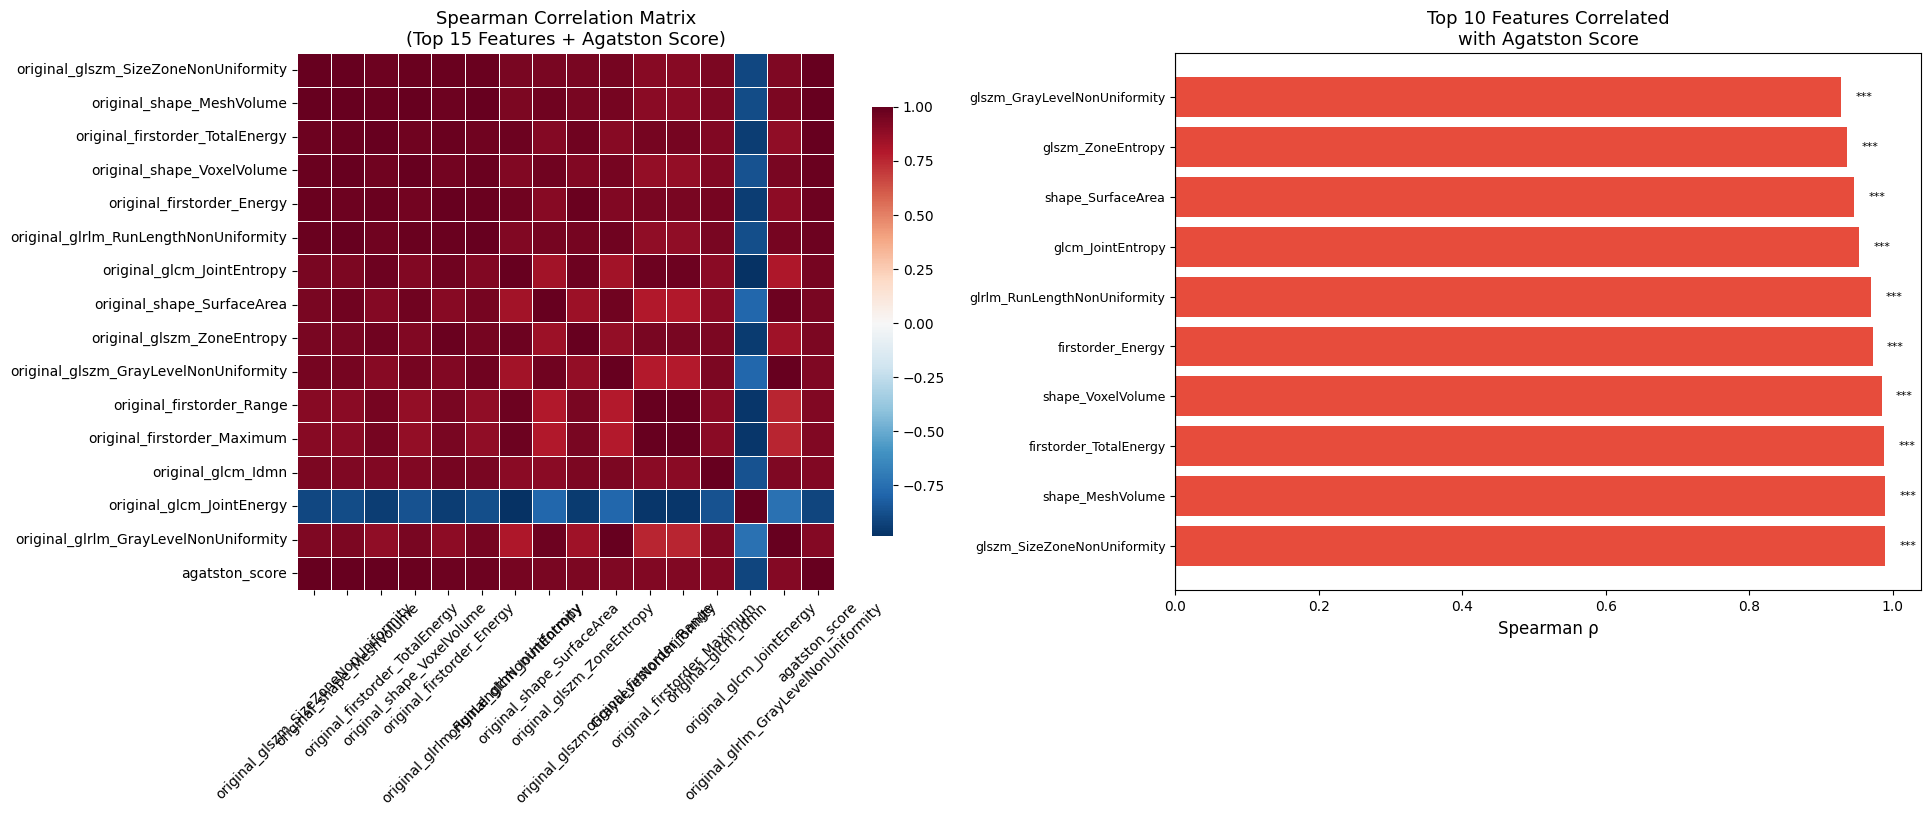

Saved: correlation_analysis.png


In [ ]:
# ── Correlation Matrix Heatmap ───────────────────────────────────────────────
# Show correlations between top significant features and Agatston score
# Select top 15 significant features for readability

top_features = corr_df.head(15)['feature'].tolist()
plot_cols     = top_features + ['agatston_score']
corr_matrix   = df[plot_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Heatmap of feature-feature correlations
sns.heatmap(
    corr_matrix,
    ax=axes[0],
    cmap='RdBu_r',
    center=0,
    annot=False,
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Spearman Correlation Matrix\n(Top 15 Features + Agatston Score)', 
                   fontsize=13)
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)
axes[0].tick_params(axis='y', rotation=0)

# Bar chart: top features correlated with Agatston score
top10 = corr_df.head(10)
colors = ['#e74c3c' if r > 0 else '#3498db' for r in top10['spearman_rho']]
bars = axes[1].barh(range(len(top10)), top10['spearman_rho'], color=colors)
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels([f.replace('original_', '') for f in top10['feature']], 
                         fontsize=9)
axes[1].set_xlabel('Spearman ρ', fontsize=12)
axes[1].set_title('Top 10 Features Correlated\nwith Agatston Score', fontsize=13)
axes[1].axvline(x=0, color='black', linewidth=0.8)

# Add significance markers
for i, (_, row) in enumerate(top10.iterrows()):
    marker = '***' if row['p_value'] < 0.001 else ('**' if row['p_value'] < 0.01 
              else ('*' if row['p_value'] < 0.05 else ''))
    if marker:
        x = row['spearman_rho']
        axes[1].text(x + 0.02 * np.sign(x), i, marker, va='center', fontsize=8)

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: correlation_analysis.png")

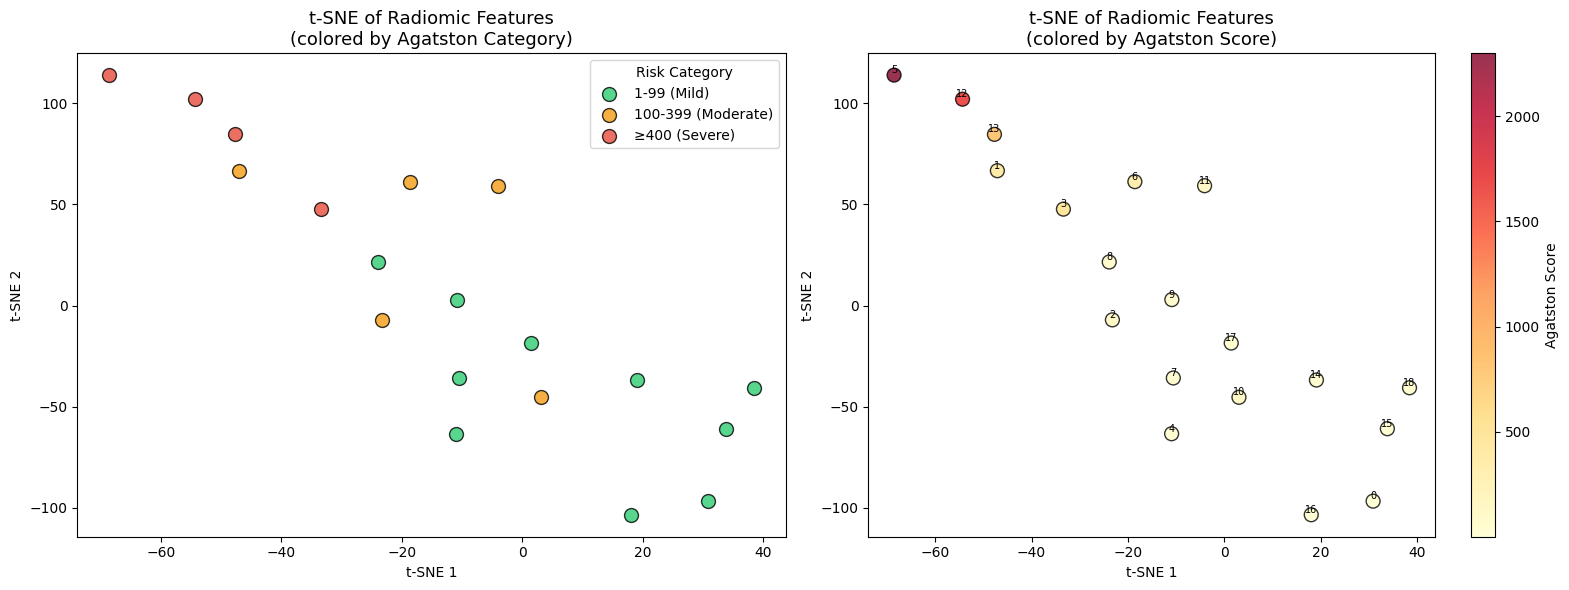

Saved: tsne_visualization.png


In [16]:
# ── t-SNE Visualization ───────────────────────────────────────────────────────
# Dimensionality reduction to visualize whether radiomic features
# naturally cluster patients by Agatston risk category.
# t-SNE preserves local structure — similar patients appear close together.

# Use top 20 most correlated features for t-SNE
tsne_features = corr_df.head(20)['feature'].tolist()
X = df[tsne_features].values

# Standardize features (t-SNE is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run t-SNE (perplexity must be < n_samples)
tsne = TSNE(n_components=2, perplexity=5, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Plot colored by Agatston category
category_colors = {
    '1-99 (Mild)':       '#2ecc71',
    '100-399 (Moderate)':'#f39c12', 
    '≥400 (Severe)':     '#e74c3c',
    '0 (None)':          '#95a5a6'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# t-SNE colored by category
for cat, color in category_colors.items():
    mask = df['agatston_category'] == cat
    if mask.sum() == 0:
        continue
    ax1.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=color, label=cat, s=100, alpha=0.8, edgecolors='black')

ax1.set_title('t-SNE of Radiomic Features\n(colored by Agatston Category)', fontsize=13)
ax1.set_xlabel('t-SNE 1')
ax1.set_ylabel('t-SNE 2')
ax1.legend(title='Risk Category', loc='best')

# t-SNE colored by continuous Agatston score
sc = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1],
                 c=df['agatston_score'].values,
                 cmap='YlOrRd', s=100, alpha=0.8, edgecolors='black')
plt.colorbar(sc, ax=ax2, label='Agatston Score')
ax2.set_title('t-SNE of Radiomic Features\n(colored by Agatston Score)', fontsize=13)
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')

# Annotate patient IDs
for i, pid in enumerate(df.index):
    ax2.annotate(str(pid), (X_tsne[i, 0], X_tsne[i, 1]),
                 fontsize=7, ha='center', va='bottom')

plt.tight_layout()
plt.savefig('tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tsne_visualization.png")
